# What is classification problem?
> is this email spam or not? >> Binary classification | as here its spam or not spam 0 or 1 like

> is this a photo of sushi, steak or pizza? >> multiclass classification ( more than one thing or another) | imagenet dataset has a 1000 object class classification and can be used for this

> multilabel classification >> multiple label options per sample


#### in binary classificaition lets say we trained model on things to detect dog and cat and then give it a image and ask whether its a cat or dog, it has 2 options thats why its binary classification

#### where as in multiclass classification : we updated our model and added another thing too lets say chicken among the images of dog and cat now its a multiclass classification as we are working on more than 2 answers now

# What we are going to cover:

> Architecture of a neural network classification model
>
> Input shapes and output shapes of a classification model (features and labels)
>
> Creating custom data to view, fit on and predict on
>
> Steps in modelling
> > Creating a model, setting a loss function and optimiser, creating a training loop, evaluating a model
>
> Saving and loading models
>
> Harnessing the power of non linearity
>
> Different classification evaluation methonds (we ll be cooking up lots of code!)

# Architecture of a classification model

### # create a model:
`model=nn.Sequential(
    nn.Linear(in_features=3, out_features=100),
    nn.Linear(in_features=100, out_features=100),
    nn.ReLU(),
    nn.Linear(in_features=100,out_features=3)
    )`

### # Setup a loss function and optimizer
`loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(params=model.parameteres(),
                           lr=0.001)`
### # Training code...
### # Training code...

In [222]:
# Neural network classification with pytorch
# classification is a problem of predicting whether something is one thing or another (there can be multiple things as the options)

#### 1. Make classification data and get it ready

In [223]:
from statistics import linear_regression
from token import NUMBER

import sklearn # very popular machine learning library | pytorch is for deep learning where as sklearn is for machine learning
from matplotlib.lines import lineMarkers

In [224]:
from sklearn.datasets import make_circles

# Make 100 samples
n_samples=1000
# Create circles
X, y= make_circles(n_samples,
                   noise=0.03,
                   random_state=42) # random_state is very similar to setting a random seed and X becuz its most likely a matrix

In [225]:
len(X)

1000

In [226]:
len(y)

1000

In [227]:
print(f"First 5 samples of X : {X[:5]}")
print(f"First 5 samples of y : {y[:5]}")

First 5 samples of X : [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y : [1 1 1 1 0]


In [228]:
# 2 features of x for 1 label of y

In [229]:
y

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [230]:
# Make DataFrame of circle data
import pandas as pd
circles=pd.DataFrame({"X1":X[:,0],
                      "X2":X[:,1],
                      "label":y})

In [231]:
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


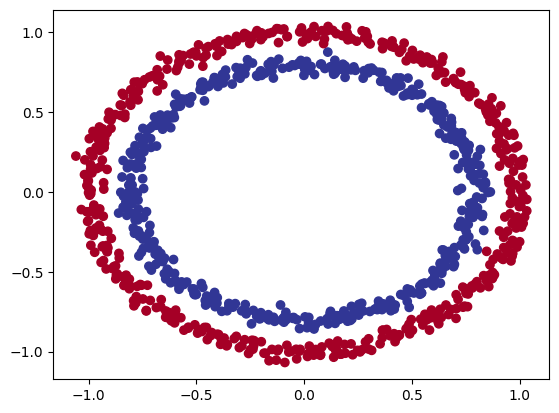

In [232]:
# Visualize, Visualize, Visualize
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0], y=X[:,1],c=y, cmap=plt.cm.RdYlBu);

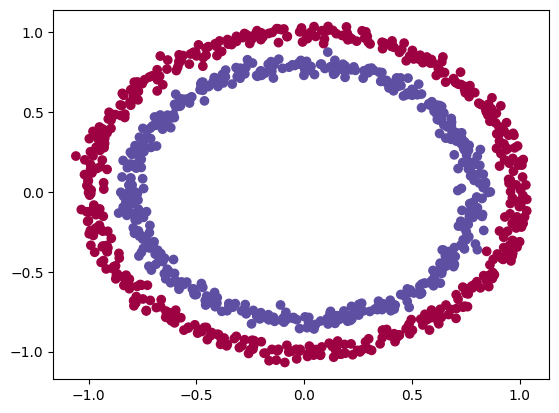

In [233]:
plt.scatter(x=X[:,0], y=X[:,1],c=y, cmap=plt.cm.Spectral);

In [234]:
import matplotlib; print(matplotlib.__version__)

3.10.8


In [235]:
# Note: the data we are working with is often referred to as a toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fundamentals.}

### Turning our data into tensors and making a training and test split

### 1.1 Check input and output shapes

In [236]:
X.shape, y.shape

((1000, 2), (1000,))

In [237]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [238]:
# View the first example of features an dlabels
X_sample=X[0]
y_sample=y[0]
print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


In [239]:
# y shape: () becuase y is scalar as it has one value thats why it doesnt have any shape

### 1.2 Turn data into tensors and create train and test splits

In [240]:
# Turn dat into tensors
import torch


In [241]:
torch.__version__


'2.10.0+cu126'

In [242]:
# Turn data into tensors
X.dtype

dtype('float64')

In [243]:
type(X)

numpy.ndarray

In [244]:
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float) # here if we dont put.type(torch.float) then X and y will remain in float64 data type which ll cause error later as default data type of numpy is float 32 and with the help  of .type(torch.float) we are converting the datatype of X and y into default data type of numpy ie float32

In [245]:
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [246]:
X.dtype, y.dtype, type(X)

(torch.float32, torch.float32, torch.Tensor)

In [247]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2,random_state=42) #0.2 = 20% of data will be test and 80% will be train

In [248]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [249]:
n_samples

1000

## 2. Building a model

let's build a model to classify our blue and red dots.

To do so, we want to:
1. Setup device agonistic code so our code will run on an accelerator (GPU) if there is one
2. Construct a model (by subclassing `nn.Module`)
3. Define a loss function and optimizer
4. Create a training and test loop

In [250]:
import torch
from torch import nn
device= "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [251]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

### Now we have setup device agnostic code, let's create a model that:

1. Subclasses `nn.Module` (almost all models in PyTorch subclass `nn.Module`)
2. Create 2 `nn.Linear() layers that are capable of handling the shapes of our data`
3. Defines a `forward()` method that outlines the forward pass (or forward computation) of the model
4. Instantiate an instance of our model class and send it to the target `device`

In [252]:
# 1. Construct a model that subclasses nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear Layers capable of handling the shapes of our data
        self.layer_1=nn.Linear(in_features=2, out_features=5) # takes in 2 features and upscales to 5 features
        self.layer_2=nn.Linear(in_features=5, out_features=1)  # takes in 5 features from previous layer and outputs a single feature (same shape as y)
        # nn.Linear: y= xA^T +b
        # ALT
        # self.two_linear_layers=nn.Sequential(
        #     nn.Linear(in_features=2, out_features=5),
        #     nn.Linear(in_features=5, out_features=1),
        # )
    # 3. Define a forward() method that outlines the forward pass
    def forward (self,x):
        return self.layer_2(self.layer_1(x)) # x-> layer_1 -> layer_2 -> output
# 4. Instantiate and instance of our model class and send it to the target device
model_0=CircleModelV0().to(device)

In [253]:
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [254]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [255]:
# Let's replicate the model above using nn.Sequential()
model_0=nn.Sequential(
    nn.Linear(in_features=2, out_features=5), # first layer
    nn.Linear(in_features=5, out_features=1) # second layer...
).to(device)

In [256]:
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [257]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]], device='cuda:0')),
             ('0.bias',
              tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]], device='cuda:0')),
             ('1.bias', tensor([-0.1213], device='cuda:0'))])

In [258]:
# Make predictions
with torch.inference_mode():
    untrained_preds=model_0(X_test.to(device))
print(f"length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"First 10 predictions: {untrained_preds[:10]}")
print(f"First 10 labels: {y_test[:10]}")

length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])
First 10 predictions: tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967],
        [ 0.2968],
        [ 0.1405],
        [ 0.2178],
        [ 0.0805],
        [-0.0284]], device='cuda:0')
First 10 labels: tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [259]:
y_test, X_test

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 0.,
         1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1.,
         1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0.,
         1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 0., 1., 0.,
         0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0.,
         1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0.,
         0., 1., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0.,
         1., 1., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1.,
         0., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 1., 0., 1.,
         1., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0.,
         0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0.,
         1., 1.]),
 tensor([[-3.7519e-01,  6.8266e-01],
         [ 1.5380e-02,  9.6003e-01],
         [-7.027

### 2.1 Setting up loss function and optimizer

Which loss fucntion or optimizer should you use?
again.. this is problem specific.

For example for regression you might want MAE or MSE ( mean absolute error or mean squared error)

For classification you might want binary cross entropy or categorical cross entropy ( cross entropy)

As a reminder, the loss function measure show wrong your models predictions are.

And for optimizers, two of the most common and useful are SGD and Adam, however PyTorch has many built-in options.

*  For the loss function we are goind to use `torch.nn.BECWithLogitsLoss()`, for more on what binary cross entropy (BCE) is , check our this article: just check the learnpytorch.io book

In [260]:
# Setup the loss function
# loss_fn = nn.BCELoss() # BCELoss= requires inputs to have gone through the sigmoid activation function prior to input to BCELoss
loss_fn=nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid activation function built-in

optimizer = torch.optim.SGD(model_0.parameters(), lr=0.1)

In [261]:
# Calculate accuracy- out of 100 examples, what percentage does our model get right?
def accuracy_fn(y_true, y_pred):
    correct= torch.eq(y_true, y_pred).sum().item()
    acc=(correct/len(y_pred))*100
    return acc

## 3. Train model

To train our model, we need to build the training loop

for epoch in the range
do the forward pass
calculate the loss
optimizer zero grad
loss backward
optimzer step step step

1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward(back propagation)
5. Optimizer step (gradient descent)

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw **logits**.

We can convert these **logits** into prediction probabilites by passing them to some kind of activation function (e.g. sigmoid for binary classification and softmax for multiclass classification ).

Then we can convert our model's prediction probabilitese to prediction labels by either rouding them or taking the `argmax()`

In [262]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
    y_logits=model_0(X_test.to(device))[:5]
y_logits #these are just logit values later using sigmoid we are converrting these values into probabilites and later rounding the probability to 0 and 1 predicitng what could be the value of label

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]], device='cuda:0')

In [263]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [264]:
# Use the sigmoid activation function on our model logits to turn them into prediction probabilities

y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]], device='cuda:0')

In [265]:
torch.round(y_pred_probs)

tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.]], device='cuda:0')

### For our prediction probability values, we need to perform a range-style rounding on them:
* `y_pred_probs` >=0.5, y=1 (class 1)
* `y_pred_probs` <0.5, y=0 (class0)

In [266]:
# Find the predicted labels
y_preds=torch.round(y_pred_probs)

#IN full (logits -> pred probs -> pred labels)
y_pred_labels=torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 1., 0., 1.], device='cuda:0')

## 3.2 Building a training and testing loop

In [267]:
!nvidia-smi

Sun Mar 15 14:11:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.83                 Driver Version: 581.83         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   53C    P8              4W /   41W |     388MiB /   6144MiB |      5%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [268]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
for epoch in range(epochs):
    ### Training
    model_0.train()

    # 1. Forward pass (model outputs raw logits)
    y_logits = model_0(X_train).squeeze() # squeeze to remove extra `1` dimensions, this won't work unless model and data are on same device
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labls

    # 2. Calculate loss/accuracy
    # loss = loss_fn(torch.sigmoid(y_logits), # Using nn.BCELoss you need torch.sigmoid()
    #                y_train)

# BCELoss → needs sigmoid applied first → loss_fn(torch.sigmoid(y_logits), y_train)
# BCEWithLogitsLoss → applies sigmoid internally → loss_fn(y_logits, y_train)
# Both do the same thing. BCEWithLogitsLoss is preferred because it's numerically more stable.

    loss = loss_fn(y_logits, # Using nn.BCEWithLogitsLoss works with raw logits
                   y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69796, Accuracy: 51.88% | Test loss: 0.69440, Test acc: 58.00%
Epoch: 10 | Loss: 0.69590, Accuracy: 51.25% | Test loss: 0.69305, Test acc: 53.00%
Epoch: 20 | Loss: 0.69490, Accuracy: 51.62% | Test loss: 0.69254, Test acc: 49.50%
Epoch: 30 | Loss: 0.69435, Accuracy: 51.12% | Test loss: 0.69236, Test acc: 49.50%
Epoch: 40 | Loss: 0.69401, Accuracy: 50.88% | Test loss: 0.69232, Test acc: 51.00%
Epoch: 50 | Loss: 0.69378, Accuracy: 50.25% | Test loss: 0.69234, Test acc: 50.00%
Epoch: 60 | Loss: 0.69362, Accuracy: 50.00% | Test loss: 0.69239, Test acc: 51.50%
Epoch: 70 | Loss: 0.69351, Accuracy: 50.25% | Test loss: 0.69246, Test acc: 51.00%
Epoch: 80 | Loss: 0.69342, Accuracy: 49.88% | Test loss: 0.69254, Test acc: 50.00%
Epoch: 90 | Loss: 0.69336, Accuracy: 49.88% | Test loss: 0.69262, Test acc: 53.00%


## 4. Make predictiobns and evaluate the model

From the metrics it looks like our model isnt learning anything....
so to inspect it lets make some predictions  and make them visual

tin other owrds visualize visualize visualize!

to dio so we are going to import a function called `plot_prediction_boundary()`

In [269]:
import requests # request is for going to a website and asking hey i would like to take this code from you can u give it to me
from pathlib import Path
# Download helper functions from learng ptorch repo(if its not already downloaded)
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download")
else:
    print("Doanload helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f: #creating file name helper_function which is writable type
        f.write(request.content)



from helper_functions import plot_predictions,plot_decision_boundary


helper_functions.py already exists, skipping download


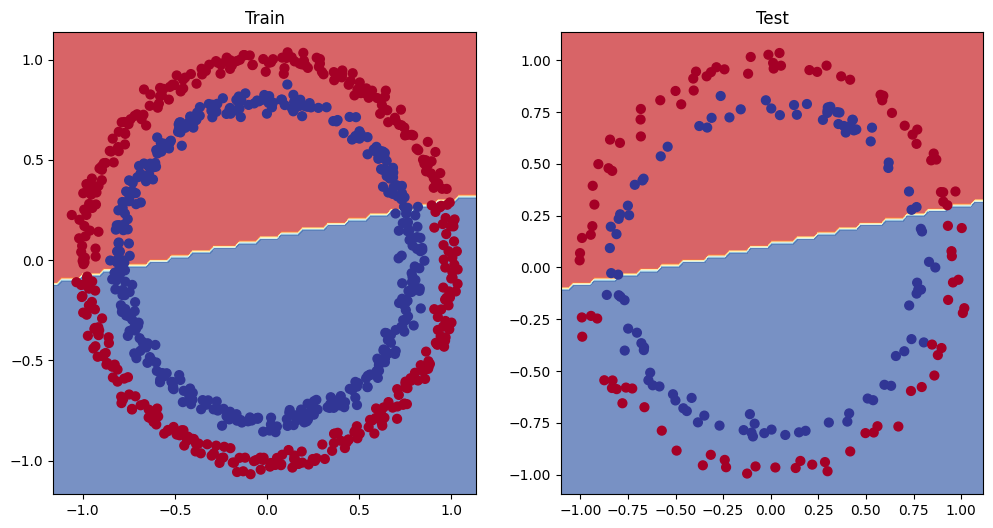

In [270]:
# Plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

# 5. Improving a model (from a model perspective)

* Add more layerss- give the model more chances to learn about patterns in the data
* Add more hidden units like right now we have 5 hidden units we can go from 5 to 10
* Fit for longer
* Changing the activation functions
* Change the learning rate (amount the optimizer will adjust in every epoch and if its too small our model will never learn as it ll take forever and if the learning rate it too high then our model might explode.  `Exploding gradient problem: Describes a situation in the trainging of neural netowrks where the gradients used to update the weights grow exponenetially, thiss prevents the backpropagation algorithm from making reasonable updates to the weights  and learning becomes unstable`
* Change the loss function

### These options are all from a model's perspective because they deal directly with the model, rather than data.

### And becausse these options are all values we ( as machine learning engineers and data scientists) can change, they are referred as hyperparameters.


`Let's try and improve our model by:`

`* Adding more hidden units: 5->10`

`* Increasse the number of layers: 2->3`

`* Increase the number of epochs: 100->1000`

In [271]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1=nn.Linear(in_features=2, out_features=10)
        self.layer_2=nn.Linear(in_features=10, out_features=10)
        self.layer_3=nn.Linear(in_features=10, out_features=1)

    def forward(self, x):
        # z=self.layer_1(x)
        # z=self.layer_2(x)
        # z=self.layer_3(x)
        # return z
        #Alternate faster way is :
        return self.layer_3(self.layer_2(self.layer_1(x))) # x is going in layer 1 and then output of layer 1 is going to layer 2 and thn output of layer 2 is going to layer 3

model_1=CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [272]:
#Create a loss function
loss_fn=nn.BCEWithLogitsLoss()
# Create optimizer function
optimizer=torch.optim.SGD(model_1.parameters(), lr=0.1)

In [273]:
# Write a training and evaluation loop for model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#Train for longer
epochs = 1000

#Put data on the target device
X_train, y_train= X_train.to(device), y_train.to(device)
X_test, y_test= X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_1.train()

    #1. Forward pass
    y_logits = model_1(X_train).squeeze()
    y_preds=torch.round(torch.sigmoid(y_logits)) # logits-> pred probabilities -> prediction labels
    # Calculate the loss
    loss = loss_fn(y_logits, y_train)
    acc=accuracy_fn(y_true=y_train,
                     y_pred=y_pred)

    #3. Optimizer zero grad
    optimizer.zero_grad()

    #4. Loss backward (backpropagation)
    loss.backward()

    #5. Optimizer step (gradient descent)
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        #1. Forward pas
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        #2. Calculate the loss
        test_loss=loss_fn(test_logits, y_test)
        test_acc=accuracy_fn(y_true=y_test,y_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f} | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396 | Acc: 49.38 | Test loss: 0.69261 | Test acc: 51.00%
Epoch: 100 | Loss: 0.69305 | Acc: 49.38 | Test loss: 0.69379 | Test acc: 48.00%
Epoch: 200 | Loss: 0.69299 | Acc: 49.38 | Test loss: 0.69437 | Test acc: 46.00%
Epoch: 300 | Loss: 0.69298 | Acc: 49.38 | Test loss: 0.69458 | Test acc: 45.00%
Epoch: 400 | Loss: 0.69298 | Acc: 49.38 | Test loss: 0.69465 | Test acc: 46.00%
Epoch: 500 | Loss: 0.69298 | Acc: 49.38 | Test loss: 0.69467 | Test acc: 46.00%
Epoch: 600 | Loss: 0.69298 | Acc: 49.38 | Test loss: 0.69468 | Test acc: 46.00%
Epoch: 700 | Loss: 0.69298 | Acc: 49.38 | Test loss: 0.69468 | Test acc: 46.00%
Epoch: 800 | Loss: 0.69298 | Acc: 49.38 | Test loss: 0.69468 | Test acc: 46.00%
Epoch: 900 | Loss: 0.69298 | Acc: 49.38 | Test loss: 0.69468 | Test acc: 46.00%


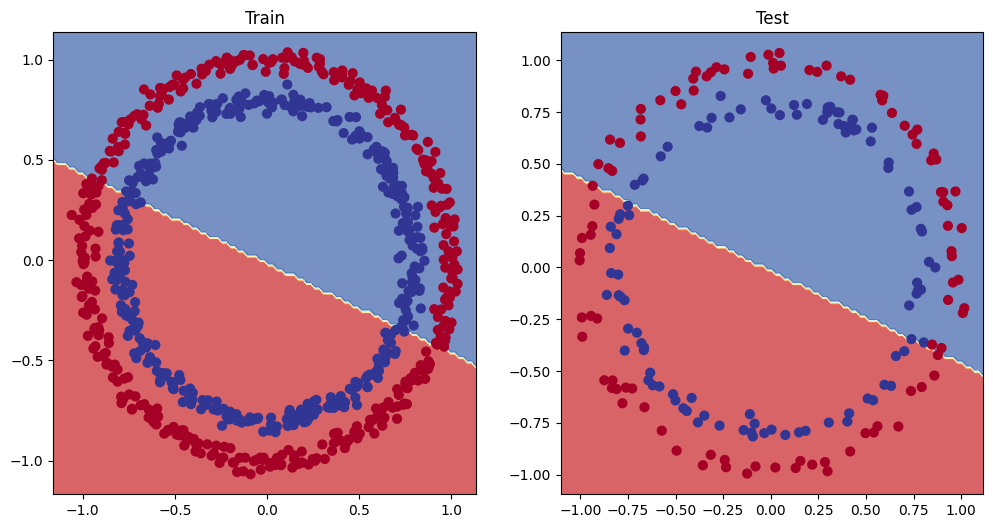

In [274]:
#  Plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

### 5.1 Preparing data to see if our model can fit a straight line

One way to troubleshoot a larger problem is to test our a smaller problem.

In [275]:
# Create some data (same as notebook 01)
weight =0.7
bias=0.3
start =0
end =1
step = 0.01

# Create data
X_regression= torch.arange(start, end, step).unsqueeze(dim=1)
y_regression=weight * X_regression + bias # linear regression formula without epsilon

# Check the data
print(len(X_regression))
X_regression[:5],y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [276]:
# Create train and test splitts
train_split=int(0.8*len(X_regression))
X_train_regression, y_train_regression=X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression=X_regression[train_split:], y_regression[train_split:]

# Check the lengths of each
len(X_train_regression), len(y_train_regression), len(X_test_regression), len(y_test_regression)

(80, 80, 20, 20)

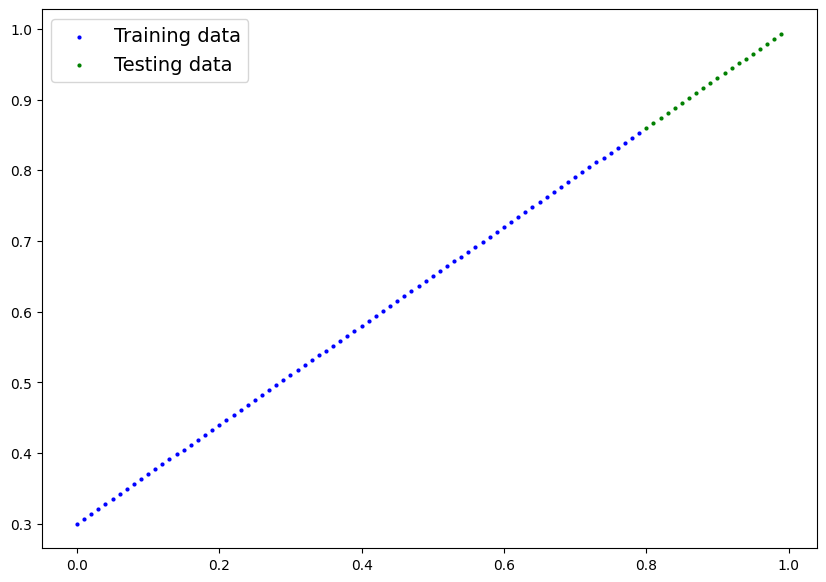

In [277]:
plot_predictions(train_data=X_train_regression,
                 train_labels=y_train_regression,
                 test_data=X_test_regression,
                 test_labels=y_test_regression)

### 5.2 Adjusting `model_1` to fit a straight line

In [278]:
X_train_regression[:10]

tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900]])

In [279]:
# this x train regression has only 1 feature but we have 2 in our classification model

model_2=nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1),
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [280]:
## Loss and optimizer
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(params=model_2.parameters(),
                          lr=0.01)


In [281]:
# Train the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put the data on target device
X_train_regression, y_train_regression=X_train_regression.to(device), y_train_regression.to(device)
X_test_regression = X_test_regression.to(device)
y_test_regression = y_test_regression.to(device)

# Training
for epoch in range(epochs):
    y_pred=model_2(X_train_regression)
    loss=loss_fn(y_pred, y_train_regression)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #Testing
    model_2.eval()
    with torch.inference_mode():
        test_pred=model_2(X_test_regression)
        test_loss=loss_fn(test_pred, y_test_regression)
    # Print out whats happening
    if epoch%100==0:
        print(f"epoch: {epoch} | Loss: {loss:.5f} | Test loss: {test_loss:.5f} ")

epoch: 0 | Loss: 0.75986 | Test loss: 0.91103 
epoch: 100 | Loss: 0.02858 | Test loss: 0.00081 
epoch: 200 | Loss: 0.02533 | Test loss: 0.00209 
epoch: 300 | Loss: 0.02137 | Test loss: 0.00305 
epoch: 400 | Loss: 0.01964 | Test loss: 0.00341 
epoch: 500 | Loss: 0.01940 | Test loss: 0.00387 
epoch: 600 | Loss: 0.01903 | Test loss: 0.00379 
epoch: 700 | Loss: 0.01878 | Test loss: 0.00381 
epoch: 800 | Loss: 0.01840 | Test loss: 0.00329 
epoch: 900 | Loss: 0.01798 | Test loss: 0.00360 


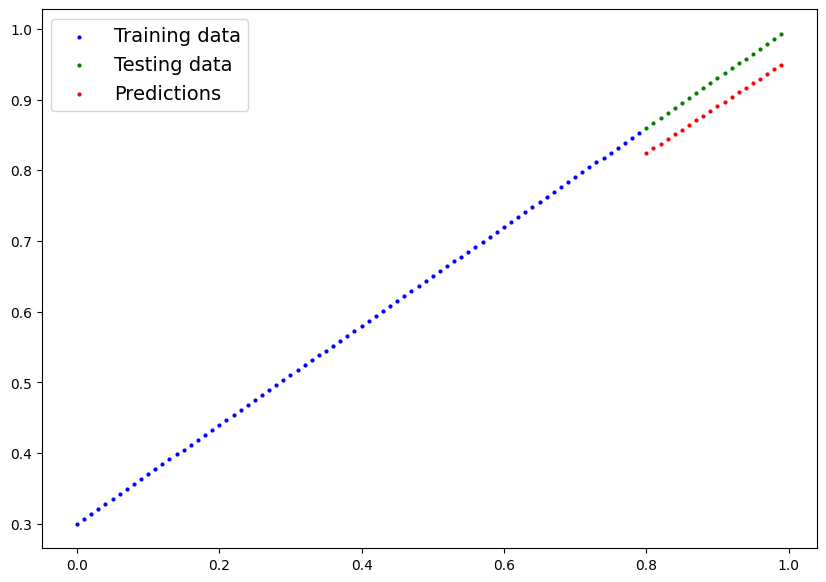

In [282]:
# turn on evualuation mode
model_2.eval()

#make predictions (inference)
with torch.inference_mode():
    y_preds=model_2(X_test_regression)

#plot data and predictions
plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu())

## 6. The missing piece: non-linearity

"What pattern could you draw if you were given an infininte amount of a straight and non straight lines?"

Or in machine learning terms, an infinite (but really it is finite) of linear and non linear function?

### 6.1 Recreating non-linear data (red and blue circles)

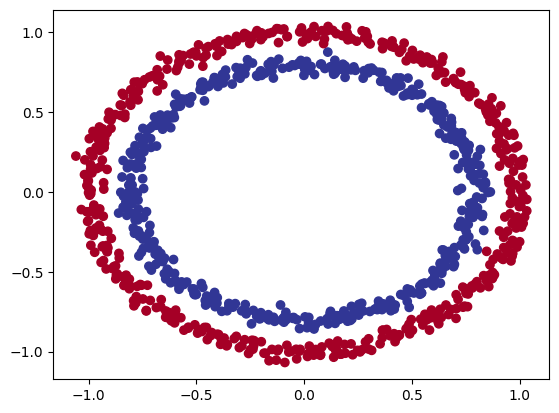

In [283]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets  import make_circles

n_samples=1000

X, y= make_circles(n_samples,
                   noise=0.03,
                   random_state=42)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu);

In [284]:
# Convert data to tensors and then to train and test splits
import torch
from sklearn.model_selection import train_test_split

#Turn data into tensors
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

#Split into train and test sets
X_train, X_test,  y_train, y_test = train_test_split(X,
                                                     y,
                                                     test_size=0.2,
                                                     random_state=42)

In [285]:
X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Building amodel with non linearity

* Linear=straight line
* Non linear= not straight line


Artificial neural networks are a large combination of linear (straight) and non-straight (non linear) functions which are potentially able to find patterns in data

In [286]:
# Build a model with non linear activation functions
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1=nn.Linear(in_features=2, out_features=10)
        self.layer_2=nn.Linear(in_features=10, out_features=10)
        self.layer_3=nn.Linear(in_features=10, out_features=1)
        self.relu= nn.ReLU() # relu is non linear activation function whihc turns negative values to zero and keeps positive value as it is _/ graph
        self.sigmoid =nn.Sigmoid()
    def forward(self, x):
        # Where should we put our non linear activation functions?
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
model_3=CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

In [287]:
# Setup loss and optimizer
loss_fn=nn.BCEWithLogitsLoss()
optimizer= torch.optim. SGD(params=model_3.parameters(),
                            lr=1)


In [288]:
# Spam or not spam
# Credit cards = fraud or not fraud
# Insurance claims = at fraud or not fraud



### 6.3 Training a model with non-linearity

In [289]:
# Random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Put all data on target decive
X_train, y_train= X_train.to(device), y_train.to(device)
X_test, y_test= X_test.to(device), y_test.to(device)

# Loop through data
epochs=1000
for epoch in range(epochs):
    ## Training
    model_3.train()

    # Forward pass
    y_logits=model_3(X_train).squeeze()  # logits because the raw output of our model without any activation functions towards the final layer classified as logits or called logits
    y_pred= torch.round(torch.sigmoid(y_logits))
    # logits -> prediction probabilities -> prediction labels

    # Calculate the loss
    loss=loss_fn(y_logits, y_train) #BCEWithLogitsLoss takes in logits as first input
    acc= accuracy_fn(y_true=y_train, y_pred=y_pred)

    #optimizer zero grad
    optimizer.zero_grad()

    # loss backward
    loss.backward()

    # step the optimizer
    optimizer.step()


    ### Testing
    model_3.eval()
    with torch.inference_mode():
        test_logits=model_3(X_test).squeeze()
        test_pred=torch.round(torch.sigmoid(test_logits))

        test_loss=loss_fn(test_logits, y_test)
        test_acc=accuracy_fn(y_true=y_test, y_pred=test_pred)
    # Print out what's happening
    if epoch%100==0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | Test loss: {test_loss:.4f} | Test acc: {test_acc:.2f}")

Epoch: 0 | Loss: 0.6929 | Acc: 50.00% | Test loss: 0.6926 | Test acc: 50.00
Epoch: 100 | Loss: 0.5772 | Acc: 86.38% | Test loss: 0.5762 | Test acc: 86.50
Epoch: 200 | Loss: 1.4209 | Acc: 50.00% | Test loss: 0.5730 | Test acc: 62.50
Epoch: 300 | Loss: 0.2256 | Acc: 97.38% | Test loss: 0.2157 | Test acc: 97.00
Epoch: 400 | Loss: 0.0256 | Acc: 100.00% | Test loss: 0.0445 | Test acc: 100.00
Epoch: 500 | Loss: 0.0093 | Acc: 100.00% | Test loss: 0.0244 | Test acc: 100.00
Epoch: 600 | Loss: 0.0056 | Acc: 100.00% | Test loss: 0.0174 | Test acc: 100.00
Epoch: 700 | Loss: 0.0039 | Acc: 100.00% | Test loss: 0.0142 | Test acc: 100.00
Epoch: 800 | Loss: 0.0030 | Acc: 100.00% | Test loss: 0.0124 | Test acc: 100.00
Epoch: 900 | Loss: 0.0025 | Acc: 100.00% | Test loss: 0.0112 | Test acc: 100.00


In [290]:
model_3.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 1.1393,  2.9950],
                      [-2.3731,  3.2759],
                      [-0.1549,  0.1427],
                      [-4.0026, -1.5087],
                      [ 0.2241, -4.5599],
                      [ 2.7876, -1.4063],
                      [ 3.1246,  0.5085],
                      [ 0.3410, -0.0998],
                      [ 1.8683,  1.9714],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-2.0770, -1.9814, -0.2872, -2.1441, -2.3655, -1.7626, -1.1876, -0.4252,
                      -1.5557, -0.6984], device='cuda:0')),
             ('layer_2.weight',
              tensor([[-0.6655, -0.9520,  0.2441, -0.9235, -0.8668, -0.6966, -0.6015,  0.2555,
                       -0.7075, -0.0997],
                      [ 1.6437,  1.8742,  0.1331,  2.1095,  1.2844,  0.7826,  1.0010,  0.0566,
                        1.3155, -0.1927],
                      [-0.3133, -0.124

### 6.4 Evaluating a model trained with non linear activation fucntions

In [291]:
#  Makes predictions
model_3.eval()
with torch.inference_mode():
    y_preds=torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

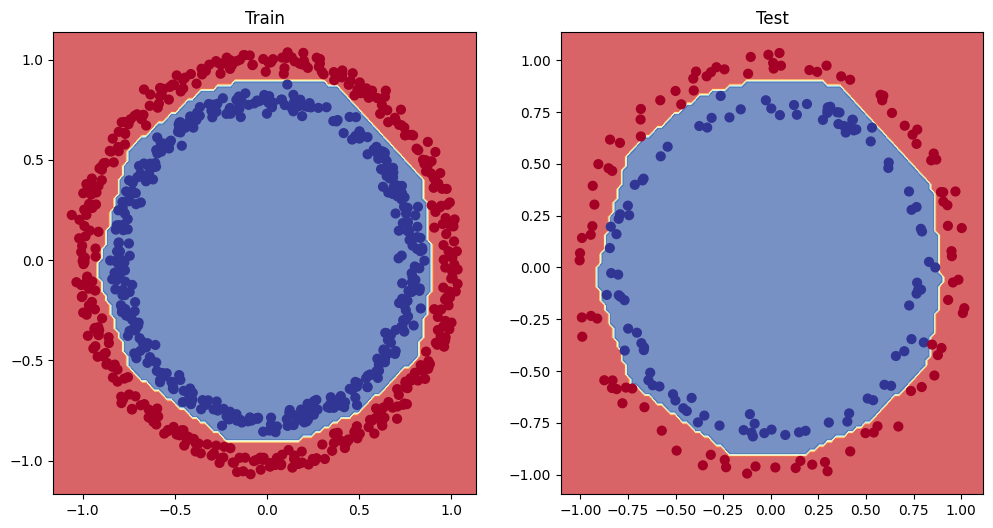

In [292]:
# Plot decision boundaries
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

<Axes: >

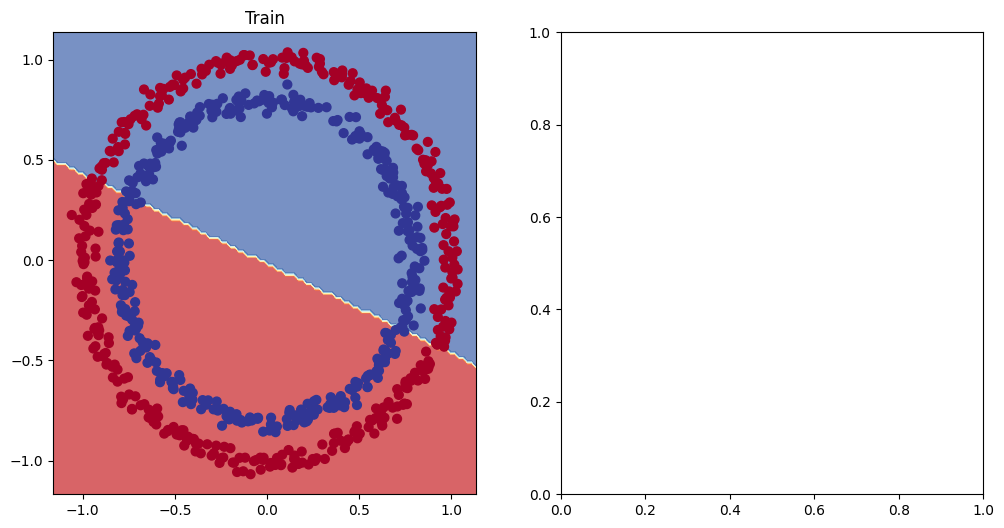

In [293]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1,2,2)


### 7. Replicating non linear activation functions

Neural networks, rather than us telling the model what to learn, we give it the tools to discover patterns in data it tries to figure out the patterns on its own.

And these tools are linear & non-linear functions.

In [294]:
# Create a tensor
A=torch.arange(-10,10,1,dtype=torch.float32)
A.dtype

torch.float32

In [295]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

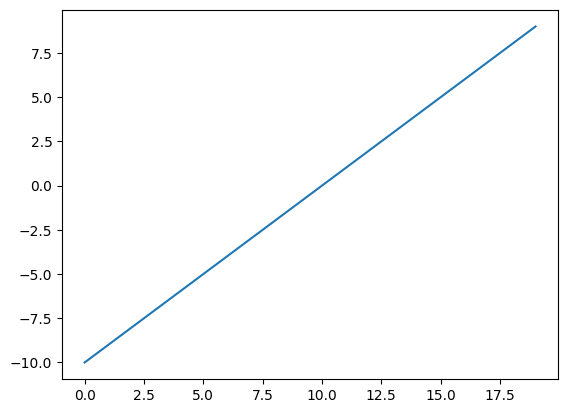

In [296]:
# Visualize the tensor
plt.plot(A)

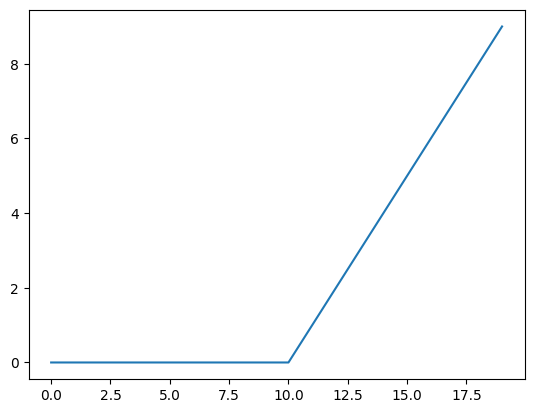

In [297]:
plt.plot(torch.relu(A))

In [298]:
def relu(x: torch.Tensor) -> torch.Tensor:
    return torch.maximum(torch.tensor(0), x) # inputs must be tensors

In [299]:
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

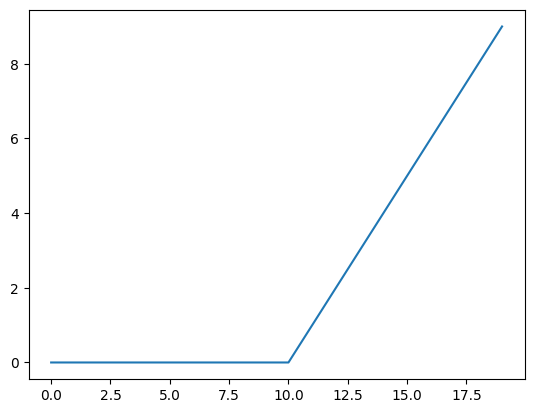

In [300]:
plt.plot(relu(A))
# [<matplotlib.lines.Line2D at 0x1619206c440>] this in output can be removed just by adding ;at the end of plt.plot();

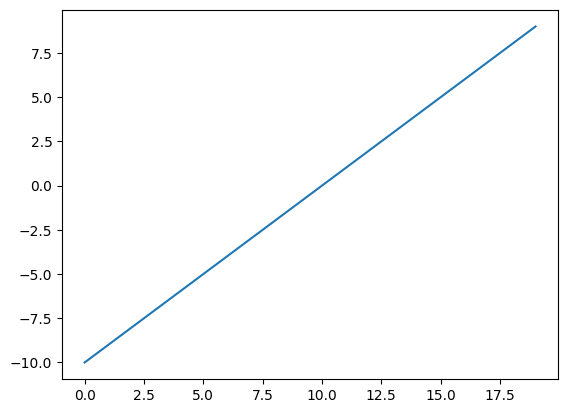

In [301]:
plt.plot(A)

In [302]:
# Now let's do the same for sigmoid
def sigmoid(x):
    return 1/(1+torch.exp(-x))
sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

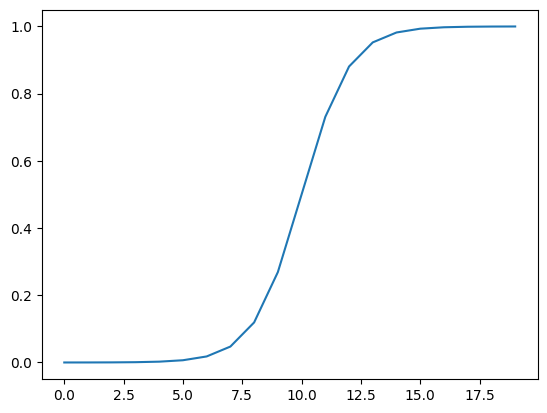

In [303]:
plt.plot(sigmoid(A))

# 8. Putting it all together with a multi-class classification problem

* Binary classification= one thing or another (cat vs dog, spam vs not spam, fraud vs not fraud)
* Multi class classification= more than one thing or another (cat vs dog vs chicken)

### 8.1 Creating a toy multi class dataset

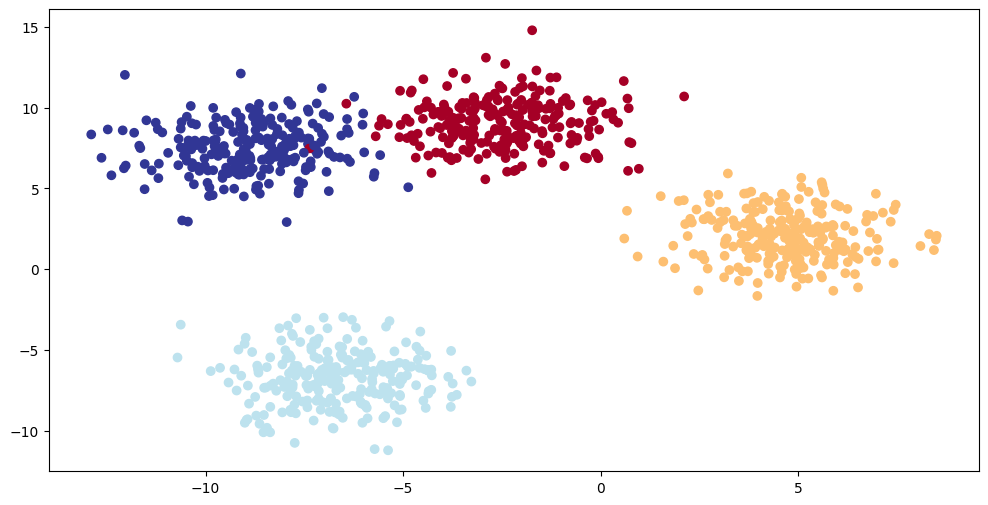

In [304]:
# Import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameterss for data creation
NUM_CLASSES=4
NUM_FEATURES=2
RANDOM_SEED=42    # we generally write hyper parameters that we write at the start at the notebook are written in capital, just a way of saying hey u can change these

#1. Create multi class data
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5, # give the clusters a little shakeup
                            random_state=RANDOM_SEED)

# 2. Turn dat into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

#3. Split into training and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)

#4. Plot data (Visuzlize, visuzlize, visualize)
plt.figure(figsize=(12,6))
plt.scatter(X_blob[:,0], X_blob[:,1], c=y_blob, cmap=plt.cm.RdYlBu)


### 8.2 Building a multi class classification model in pytorch

In [305]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [342]:
# Build a multi class classification model
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        """Initializes multi-class classification model.

        Args:
            input_features (int): Number of input features to the model
            output_features (int): Number of output features (number of output classes)
            hidden_units (int): Number of hidden units between layers, default 8

        Returns:

        Example:
        """
        super().__init__()
        self.linear_layer_stack=nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
            )
    def forward(self, x):
        return self.linear_layer_stack(x)
#Create an instance of BlobModel and send it to the target device
model_4=BlobModel(input_features=2,
                  output_features=4,
                  hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [343]:
X_blob_train, y_blob_train

(tensor([[ 5.0405,  3.3076],
         [-2.6249,  9.5260],
         [-8.5240, -9.0402],
         ...,
         [-1.7366,  9.7850],
         [-6.8139, -7.1006],
         [-9.0311,  4.5007]], device='cuda:0'),
 tensor([1, 0, 2, 2, 0, 0, 0, 1, 3, 0, 0, 0, 3, 2, 3, 2, 1, 1, 3, 2, 2, 2, 3, 1,
         3, 2, 3, 0, 1, 0, 0, 1, 1, 3, 0, 2, 2, 1, 1, 3, 1, 1, 2, 3, 3, 0, 0, 0,
         1, 0, 0, 0, 2, 0, 1, 1, 0, 0, 2, 2, 3, 1, 0, 2, 1, 3, 2, 2, 2, 1, 0, 2,
         3, 1, 1, 1, 2, 0, 0, 1, 2, 3, 1, 3, 3, 2, 3, 3, 2, 2, 1, 0, 0, 1, 2, 1,
         3, 1, 2, 1, 3, 3, 3, 0, 2, 1, 2, 3, 1, 1, 2, 0, 3, 3, 2, 0, 2, 0, 3, 2,
         0, 0, 2, 2, 0, 1, 2, 0, 3, 3, 2, 3, 2, 1, 3, 1, 1, 1, 1, 0, 0, 1, 0, 2,
         3, 0, 0, 0, 0, 0, 1, 0, 3, 0, 0, 2, 2, 0, 0, 3, 0, 3, 3, 3, 0, 2, 0, 1,
         2, 2, 2, 3, 0, 1, 1, 0, 1, 2, 0, 3, 2, 1, 3, 2, 3, 0, 3, 1, 1, 2, 2, 2,
         2, 2, 2, 0, 3, 3, 2, 1, 1, 2, 3, 1, 0, 0, 1, 3, 0, 1, 3, 3, 2, 3, 3, 3,
         1, 0, 0, 1, 0, 3, 2, 1, 0, 3, 0, 0, 3, 1, 0, 1, 0, 2, 2

In [344]:
X_blob_train.shape, y_blob_train.shape

(torch.Size([800, 2]), torch.Size([800]))

In [345]:
torch.unique(y_blob_train)

tensor([0, 1, 2, 3], device='cuda:0')

In [346]:
torch.unique(X_blob_train)

tensor([-12.8932, -12.6338, -12.4747,  ...,  12.7091,  13.0945,  14.7934],
       device='cuda:0')

## Putting it all together part 3: setting up a loss function and optimizer for our multi class model

### 8.3 Create a loss function and an optimizer for a multi class classification model

In [347]:
# Create a loss function for multi class classification
loss_fn = nn.CrossEntropyLoss()

#Create an optimizer for multi class classification
optimizer=torch.optim.SGD(params=model_4.parameters(),
                          lr=0.1) #learning rate is a hyperparametere you can change

### 8.4 Getting prediction probablities for a multi class pytorch model


In order to evaluate and train and test our model, we need to convert out model's output (logits) to prediction probablilites and then to prediction labels.

* logits (raw output of the model) -> prediction probs (use `torch.softmax`)-> pred labels (take the argmamx of prediction probabilities)

In [348]:
 #Let's get some raw outputs of our model (logits))
model_4.eval()
with torch.inference_mode():
    y_logits=model_4(X_blob_test.to(device))
y_logits[:10]

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [-0.1497, -1.0617, -0.7107, -0.1645],
        [ 0.1539, -0.2887,  0.1520, -0.0109],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [ 0.2443, -0.2472,  0.1649,  0.0061],
        [-0.2329, -1.2120, -0.9849, -0.3004]], device='cuda:0')

In [349]:
next(model_4.parameters()).device

device(type='cuda', index=0)

In [350]:
X_blob_test.device

device(type='cuda', index=0)

In [351]:
y_blob_test[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')

In [352]:
#Convert our model's logit outputs to prediction probabilites
y_pred_probs=torch.softmax(y_logits,dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834]], device='cuda:0')
tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463]], device='cuda:0')


In [353]:
torch.sum(y_pred_probs[0])

tensor(1., device='cuda:0')

In [354]:
# Convert out model's prediction probabiliteies to predictionlabels
y_preds=torch.argmax(y_pred_probs, dim=1)
y_preds

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1], device='cuda:0')

In [355]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1], device='cuda:0')

### 8.5 Creating a training loop and testing loop for a multi class pytorch model

In [356]:
# Fit the multi class model to the data
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#Set number of epochs
epochs=100

#Put data to the target device
X_blob_train, y_blob_train=X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test=X_blob_test.to(device), y_blob_test.to(device)

#Loop through data
for epoch in range(epochs):
    ### Training
    model_4.train()
    y_logits=model_4(X_blob_train)

    y_pred=torch.softmax(y_logits,dim=1).argmax(dim=1)

    loss=loss_fn(y_logits, y_blob_train)
    acc=accuracy_fn(y_true=y_blob_train, y_pred=y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### Testing
    model_4.eval()
    with torch.inference_mode():
        test_logits=model_4(X_blob_test)
        test_preds=torch.softmax(test_logits, dim=1).argmax(dim=1)

        test_loss=loss_fn(test_logits, y_blob_test)
        test_acc=accuracy_fn(y_true=y_blob_test, y_pred=test_preds)
# Print out whats happening
    if epoch %10==0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | Test loss: {test_loss:.4f} | Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.1588 | Acc: 40.38% | Test loss: 1.0755 | Test acc: 48.00%
Epoch: 10 | Loss: 0.6448 | Acc: 96.75% | Test loss: 0.6607 | Test acc: 97.50%
Epoch: 20 | Loss: 0.4254 | Acc: 98.50% | Test loss: 0.4307 | Test acc: 100.00%
Epoch: 30 | Loss: 0.2529 | Acc: 99.12% | Test loss: 0.2451 | Test acc: 99.50%
Epoch: 40 | Loss: 0.1123 | Acc: 99.25% | Test loss: 0.1023 | Test acc: 99.50%
Epoch: 50 | Loss: 0.0663 | Acc: 99.25% | Test loss: 0.0585 | Test acc: 99.50%
Epoch: 60 | Loss: 0.0507 | Acc: 99.25% | Test loss: 0.0429 | Test acc: 99.50%
Epoch: 70 | Loss: 0.0430 | Acc: 99.25% | Test loss: 0.0349 | Test acc: 99.50%
Epoch: 80 | Loss: 0.0384 | Acc: 99.25% | Test loss: 0.0299 | Test acc: 99.50%
Epoch: 90 | Loss: 0.0352 | Acc: 99.25% | Test loss: 0.0266 | Test acc: 99.50%


In [357]:
y_logits.dtype, y_blob_train.dtype

(torch.float32, torch.int64)

In [358]:
test_pred, test_preds

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 0.,
         1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1.,
         1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0.,
         1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 0., 1., 0.,
         0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0.,
         1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0.,
         0., 1., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0.,
         1., 1., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1.,
         0., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 1., 0., 1.,
         1., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0.,
         0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0.,
         1., 1.], device='cuda:0'),
 tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0

In [359]:
#Vsualize visualize visualize

### 8.6 Making and evaluating predictions with a pytorch multi class model

In [360]:
# Make predictions
model_4.eval()
with torch.inference_mode():
    y_logits=model_4(X_blob_train)

#View the first 10 predictions
y_logits[:10]



tensor([[-1.3344,  6.3308, -6.8960, -7.8460],
        [ 3.4175, -4.6882, -7.1541, -3.3469],
        [-4.3207, -4.9367,  3.7790, -3.3399],
        [-2.7649, -3.2697,  2.8040, -2.2441],
        [ 1.7790, -4.4905, -4.9554, -1.3282],
        [ 2.7366,  0.4429, -7.4993, -6.6685],
        [ 2.5785, -6.0076, -7.1173, -1.9804],
        [-0.9690,  4.8266, -5.2035, -6.1433],
        [-2.3246, -5.8080, -2.6661,  2.7026],
        [ 2.1972, -5.1874, -5.9877, -1.6836]], device='cuda:0')

In [361]:
# Go from logits -> Prediction probabilities
y_pred_pros=torch.softmax(y_logits, dim=1)
y_pred_probs[:10]

tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463],
        [0.3381, 0.1358, 0.1929, 0.3331],
        [0.2867, 0.1841, 0.2861, 0.2431],
        [0.3554, 0.1355, 0.1740, 0.3351],
        [0.3009, 0.1841, 0.2779, 0.2371],
        [0.3595, 0.1350, 0.1695, 0.3360]], device='cuda:0')

In [362]:
# Go from pred probs to pred labels

In [363]:
y_preds=torch.argmax(y_pred_probs, dim=1)
y_preds[:10]

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')

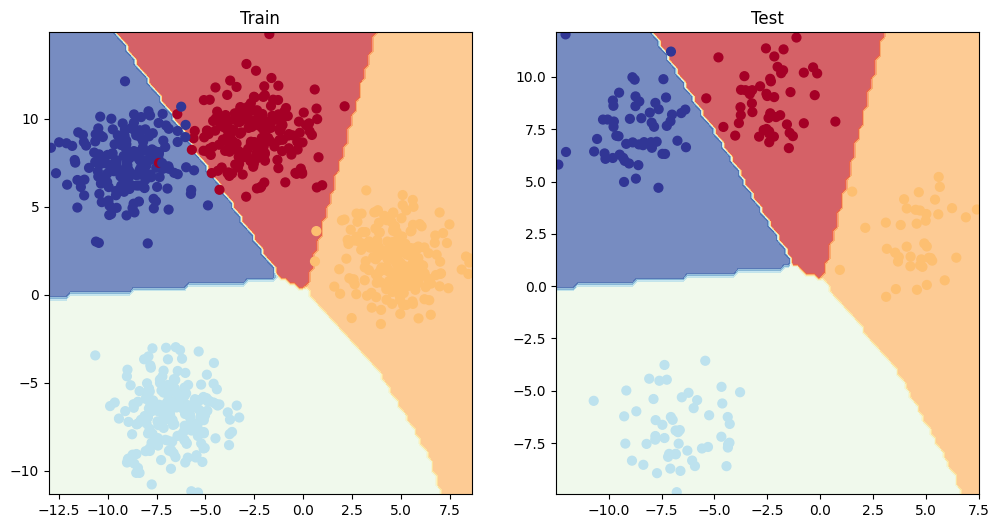

In [364]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

### 9. A few more classification metrics.... (to evaluate our classification model")

* Accuracy - out of 100 samples, how many does our model get right?

* Precision

* Recall

* Classification report

* F1-score

* Confusion matrix

In [329]:
import torchmetrics


In [330]:
!pip install torchmetrics


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [331]:
python.exe -m pip install --upgrade pip

SyntaxError: invalid syntax (1104305986.py, line 1)

In [161]:
!pip install  --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 308.2 kB/s eta 0:00:05
   ----------- ---------------------------- 0.5/1.8 MB 308.2 kB/s eta 0:00:05
   ----------------- ---------------------- 0.8/1.8 MB 380.4 kB/s eta 0:00:03
   ----------------- ---------------------- 0.8/1.8 MB 380.4 kB/s eta 0:00:03
   ----------------- ---------------------- 0.8/1.8 MB 380.4 kB/s eta 0:00:03
   ----------------------- ---------------- 1.0/1.8 MB 403


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
E:\AI-ML-Learning\.venv\Scripts\python.exe -m pip install --upgrade pip


In [162]:
import torchmetrics